# kaft · Wave Propagation
### Metric-induced geometry as a propagating wave front

Each metric defines a `speed_field` — a 2D map where value = propagation speed.  
We simulate a wave emanating from the centre and watch how the geometry bends it.

Flat geometry (Euclidean) → perfect circles.  
Curved geometry (Fisher-Rao, KL) → distorted, asymmetric fronts.  
The *shape of the wave* **is** the shape of the metric.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-e",
                "/Users/ashwinpalve/crucible/kaft", "-q"], check=True)

import sys as _sys
for k in [k for k in _sys.modules if k.startswith("kaft")]:
    del _sys.modules[k]
print("kaft reloaded ✓")

kaft reloaded ✓


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from kaft.geometry import DivergenceRegistry

r = DivergenceRegistry()

/Users/ashwinpalve/crucible/kaft/kaftenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1 · The Wave Simulation

We use a simplified **Eikonal equation** approximation.  
At each timestep, the wavefront advances proportionally to the local speed.  
`T[i,j]` = the time the wave first arrives at grid point (i,j).

In [3]:
def simulate_wave(speed_field: np.ndarray, source: tuple = None) -> np.ndarray:
    """
    Fast marching approximation — arrival time T at each grid point.
    speed_field: (H, W) array, values in (0, 1]
    Returns T: (H, W) arrival times, normalised to [0, 1]
    """
    H, W = speed_field.shape
    if source is None:
        source = (H // 2, W // 2)
    
    T = np.full((H, W), np.inf)
    T[source] = 0.0
    visited = np.zeros((H, W), dtype=bool)
    
    # Simple BFS-style fast marching (sufficient for visualisation)
    import heapq
    heap = [(0.0, source[0], source[1])]
    
    while heap:
        t, i, j = heapq.heappop(heap)
        if visited[i, j]:
            continue
        visited[i, j] = True
        
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W and not visited[ni, nj]:
                dist = np.sqrt(di**2 + dj**2)
                speed = (speed_field[i,j] + speed_field[ni,nj]) / 2
                nt = t + dist / (speed + 1e-9)
                if nt < T[ni, nj]:
                    T[ni, nj] = nt
                    heapq.heappush(heap, (nt, ni, nj))
    
    T = T / T.max()  # normalise
    return T

print("Wave engine ready ✓")

Wave engine ready ✓


## §2 · Speed Fields + Wave Fronts — side by side for all 9 metrics

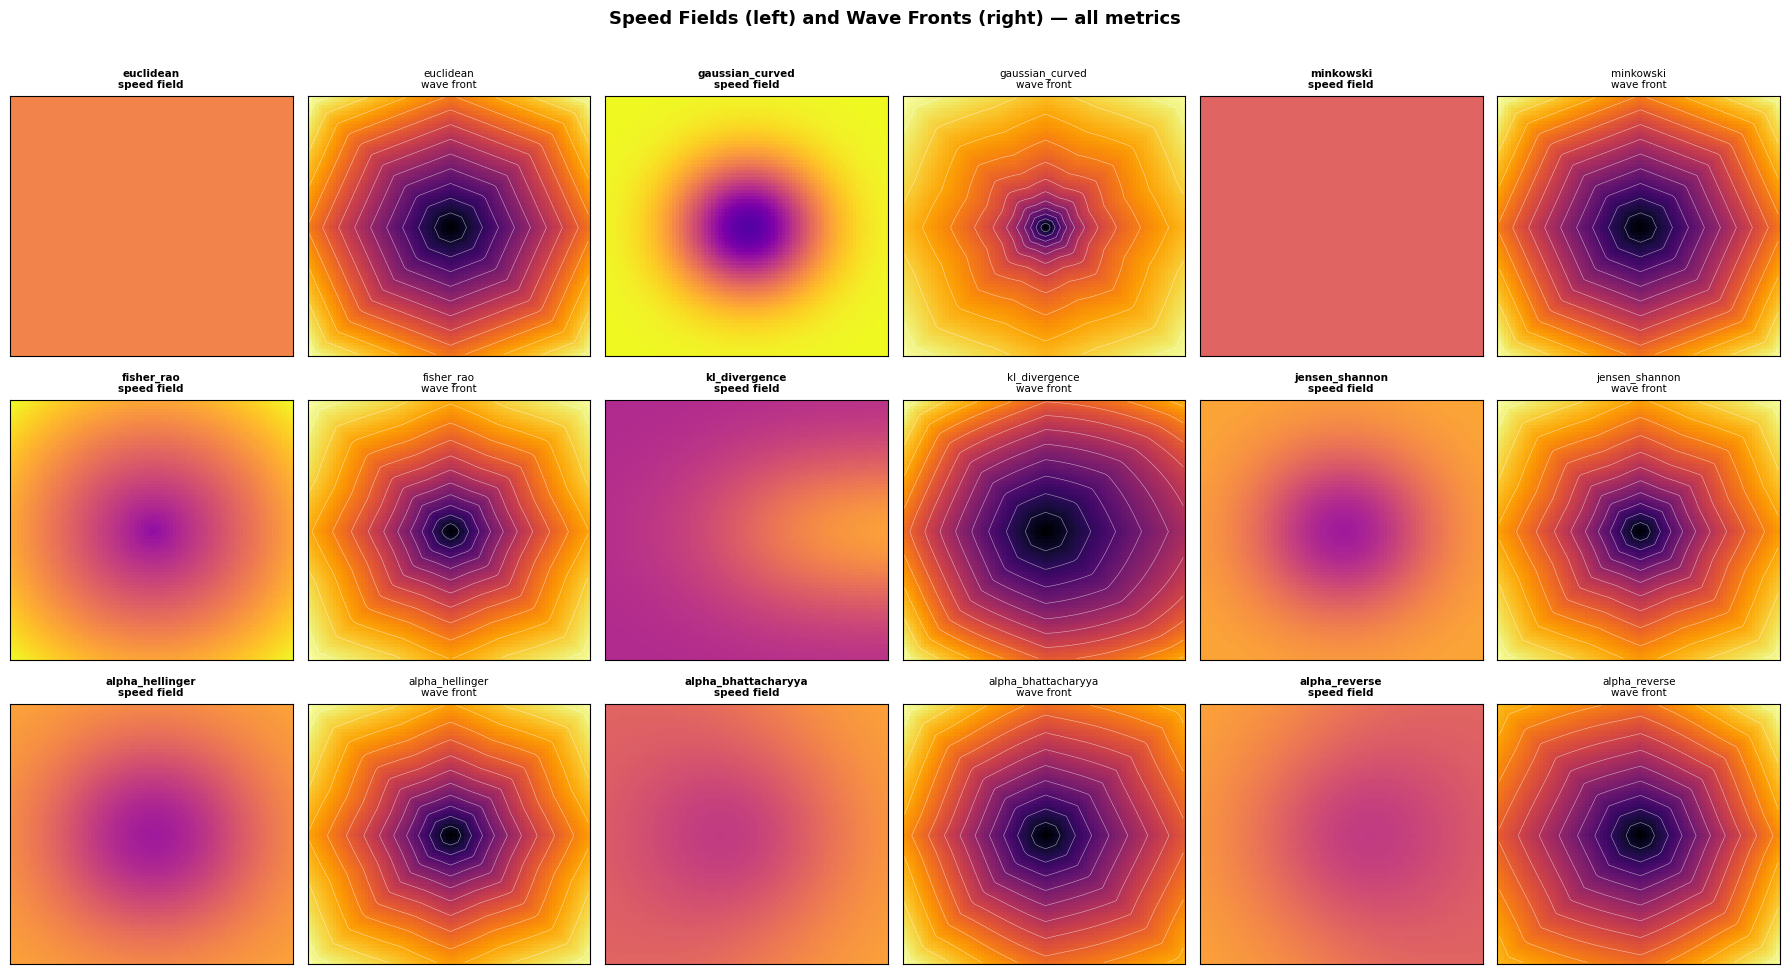

Saved: wave_propagation_all.png


In [4]:
GRID    = 80
metrics = r.available()
n       = len(metrics)
cols    = 3
rows    = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols * 2, figsize=(18, rows * 3.2))
fig.suptitle("Speed Fields (left) and Wave Fronts (right) — all metrics", 
             fontsize=13, fontweight="bold", y=1.01)

for idx, name in enumerate(metrics):
    row, col = divmod(idx, cols)
    ax_speed = axes[row][col * 2]
    ax_wave  = axes[row][col * 2 + 1]
    
    m     = r.get(name)
    field = m.speed_field(GRID)
    T     = simulate_wave(field)
    
    ax_speed.imshow(field, cmap="plasma", vmin=0, vmax=1, aspect="auto")
    ax_speed.set_title(f"{name}\nspeed field", fontsize=7.5, fontweight="bold")
    ax_speed.set_xticks([]); ax_speed.set_yticks([])
    
    # Wave front as contour lines — the geometry made visible
    ax_wave.imshow(T, cmap="inferno", aspect="auto")
    ax_wave.contour(T, levels=12, colors="white", linewidths=0.4, alpha=0.6)
    ax_wave.set_title(f"{name}\nwave front", fontsize=7.5)
    ax_wave.set_xticks([]); ax_wave.set_yticks([])

# hide any empty subplots
for idx in range(n, rows * cols):
    row, col = divmod(idx, cols)
    axes[row][col * 2].set_visible(False)
    axes[row][col * 2 + 1].set_visible(False)

plt.tight_layout()
plt.savefig("wave_propagation_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wave_propagation_all.png")

## §3 · Euclidean vs KL — the geometry contrast in one frame

Euclidean space = perfect circular wavefronts.  
KL space = asymmetric, the direction of divergence bends the propagation.

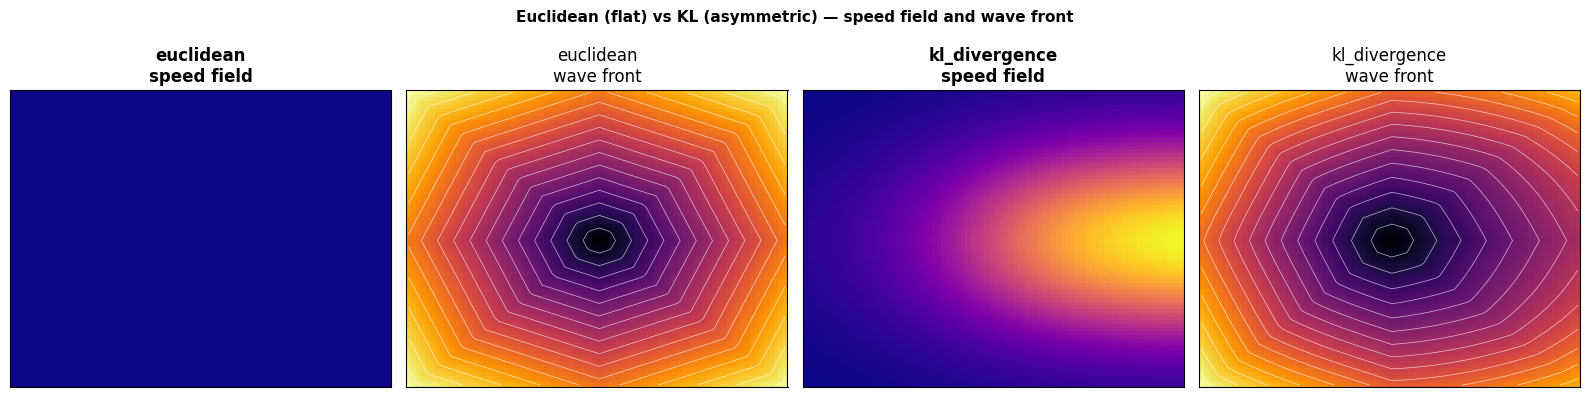

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Euclidean (flat) vs KL (asymmetric) — speed field and wave front", 
             fontsize=11, fontweight="bold")

pairs = [("euclidean", "kl_divergence")]

for pair_idx, (name_a, name_b) in enumerate(pairs):
    for col, name in enumerate([name_a, name_b]):
        m     = r.get(name)
        field = m.speed_field(GRID)
        T     = simulate_wave(field)
        
        ax_f = axes[col * 2]
        ax_w = axes[col * 2 + 1]
        
        ax_f.imshow(field, cmap="plasma", aspect="auto")
        ax_f.set_title(f"{name}\nspeed field", fontweight="bold")
        ax_f.set_xticks([]); ax_f.set_yticks([])
        
        ax_w.imshow(T, cmap="inferno", aspect="auto")
        ax_w.contour(T, levels=16, colors="white", linewidths=0.5, alpha=0.7)
        ax_w.set_title(f"{name}\nwave front")
        ax_w.set_xticks([]); ax_w.set_yticks([])

plt.tight_layout()
plt.savefig("euclidean_vs_kl_wave.png", dpi=150, bbox_inches="tight")
plt.show()